# Dataset Reformatting to YOLO preferences

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = "../yolo/1_image.png"
mask_path = "../yolo/1_mask.png"
annotation_output_path = "../yolo/generated_yolo_annotation.txt"

In [3]:
# Load mask and image in
image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Check if mask is loaded
if mask is None:
    raise FileNotFoundError(f"Mask not found at: {mask_path}")

In [4]:
# Making mask binary instead of (0 1) values we not get (0 255)
mask = mask * 255
mask = mask.astype(np.uint8)

In [5]:
# Threshold mask to ensure binary
_, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

In [6]:
# Find contours
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours is None:
    raise ValueError("No contours found in mask")

In [7]:
# Get image dimensions
height, width = mask.shape

In [8]:
# Get image shape
height, width = mask.shape

In [9]:
# Prepare annotated image
annotated_image = image.copy()

In [10]:
# Get yolo annotations
yolo_annotations = []

In [11]:
for contour in contours:
    if len(contour) < 3:
        continue  # Skip small or invalid polygons

    # Normalize polygon points
    polygon_normalized = [(x / width, y / height) for [[x, y]] in contour]

    # Format annotation string
    annotation_line = "0 " + " ".join([f"{x:.6f} {y:.6f}" for x, y in polygon_normalized])
    yolo_annotations.append(annotation_line)

    # Draw contour on image
    cv2.polylines(annotated_image, [contour], isClosed=True, color=(0, 0, 255), thickness=2)

In [12]:
# Save all yolo-style annotations to file
with open(annotation_output_path, "w") as f:
    f.write("\n".join(yolo_annotations))

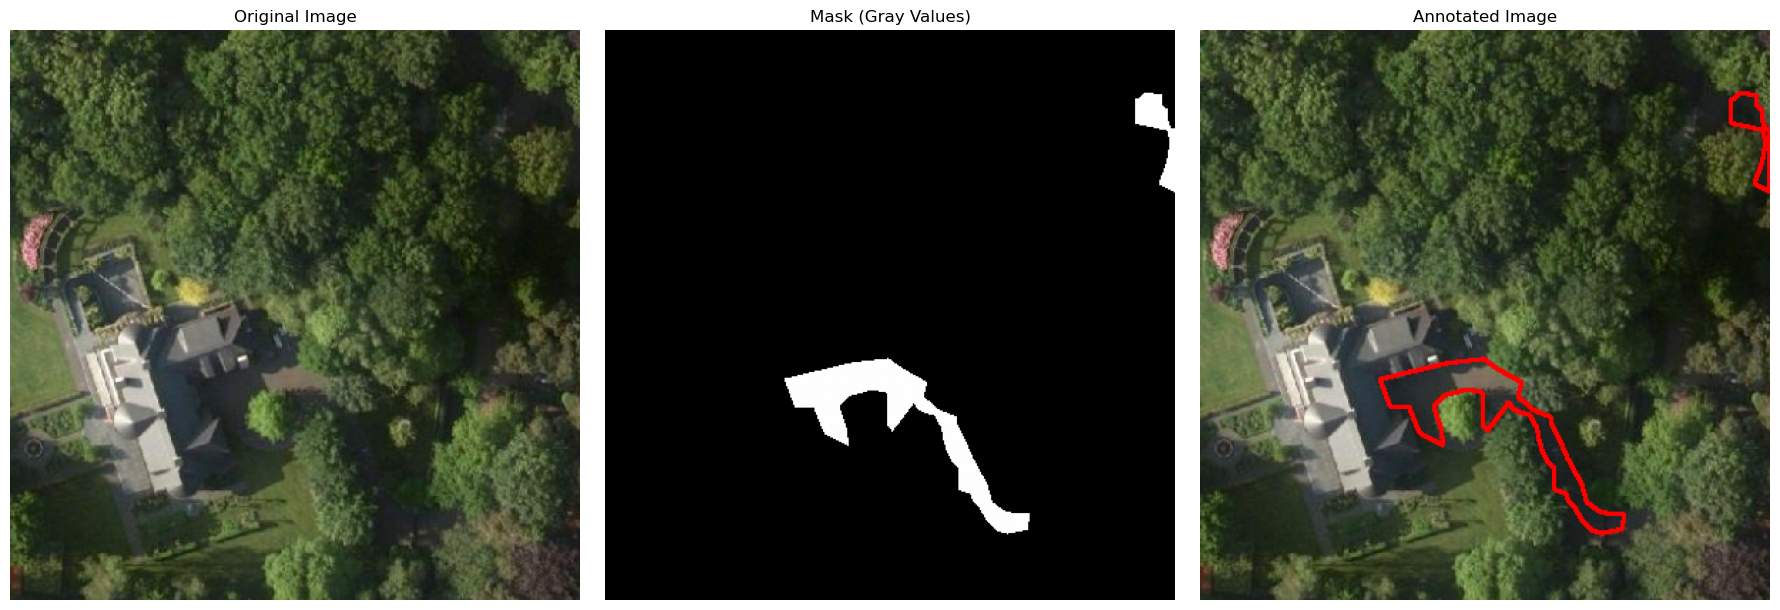

In [13]:
# Display images
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("Mask (Gray Values)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title("Annotated Image")
plt.axis("off")

plt.tight_layout()
plt.show()